# 07. 모델 해석

`06_model_finalization`에서 확정한 최종 모델(`reduced_time_age` + `RandomForest`)의
트리 기반 Feature Importance가 `distance_to_gbd_km`과 `area_m2`에 편중되어 있었다.

이 노트북에서는 Permutation Importance를 측정하여 각 변수의 실질적인 예측 기여도를 확인하고,
트리 기반 Feature Importance와 비교한다.

편중이 실제 데이터 구조에서 비롯된 것으로 확인되면 추가 탐색 없이 현재 모델을 유지한다.

편중이 트리 분기 특성에 의한 편향으로 판단되면 N_ITER 확대 등 탐색 강화를 검토한다.



- 테스트 세트 결과는 변수 기여도 해석에만 사용하며, 추가 모델 선택이나 변경을 수행하지 않는다.

## 1. 라이브러리 및 경로 설정

In [ ]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(PROJECT_ROOT / '.cache'))
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count() or 1))
(PROJECT_ROOT / '.matplotlib').mkdir(exist_ok=True)
(PROJECT_ROOT / '.cache').mkdir(exist_ok=True)
(PROJECT_ROOT / 'reports').mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

FEATURE_DATA_PATH = PROJECT_ROOT / 'data/processed/seoul_apt_trade_2025_features.csv'
MODELING_DATA_PATH = PROJECT_ROOT / 'data/processed/modeling_dataset.csv'

PERM_IMPORTANCE_PATH = PROJECT_ROOT / 'reports/06_2_permutation_importance.csv'
FINAL_FIGURE_DIR = PROJECT_ROOT / 'reports/figures'
FINAL_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 2. 데이터 로드

06-1과 동일하다.

In [ ]:
if FEATURE_DATA_PATH.exists():
    source_df = pd.read_csv(FEATURE_DATA_PATH, encoding='utf-8-sig')
    source_name = FEATURE_DATA_PATH.name
elif MODELING_DATA_PATH.exists():
    source_df = pd.read_csv(MODELING_DATA_PATH, encoding='utf-8-sig')
    source_name = MODELING_DATA_PATH.name
else:
    raise FileNotFoundError('모델 검증에 필요한 CSV가 없습니다. 03 또는 05 노트북을 먼저 실행하세요.')

source_df['contract_date'] = pd.to_datetime(source_df['contract_date'])
source_df = source_df.sort_values('contract_date').reset_index(drop=True)

print(f'loaded: {source_name}')
source_df.shape

loaded: seoul_apt_trade_2025_features.csv


(77359, 31)

## 3. 최종 모델 설정

06-1에서 확정한 변수 조합과 하이퍼파라미터를 그대로 사용한다.

In [ ]:
target_col = 'price_10k_krw'

# 06-1에서 확정한 변수 조합
best_feature_set = 'reduced_time_age'
numeric_features = [
    'area_m2',
    'floor',
    'age',
    'contract_month',
    'distance_to_cbd_km',
    'distance_to_ybd_km',
    'distance_to_gbd_km',
    'nearest_subway_distance_km',
    'nearest_hospital_distance_km',
    'large_mart_count_within_1km',
]
categorical_features = ['gu', 'law_dong']

# 06-1에서 확정한 하이퍼파라미터
best_params = {
    'n_estimators': 240,
    'max_depth': None,
    'min_samples_leaf': 1,
    'min_samples_split': 5,
    'max_features': 0.7,
}

columns = [target_col, 'contract_date', *numeric_features, *categorical_features]
df = source_df[columns].dropna().sort_values('contract_date').reset_index(drop=True)

train_end = pd.Timestamp('2025-09-01')
valid_end = pd.Timestamp('2025-11-01')
train_df = df[df['contract_date'] < train_end].copy()
valid_df = df[(df['contract_date'] >= train_end) & (df['contract_date'] < valid_end)].copy()
test_df = df[df['contract_date'] >= valid_end].copy()

X_train = train_df[numeric_features + categorical_features]
y_train = train_df[target_col]
X_valid = valid_df[numeric_features + categorical_features]
y_valid = valid_df[target_col]
X_test = test_df[numeric_features + categorical_features]
y_test = test_df[target_col]

print(f'train: {len(train_df)}, valid: {len(valid_df)}, test: {len(test_df)}')

train: 51986, valid: 17197, test: 8154


## 4. 최종 모델 학습

Permutation Importance는 학습된 모델에 평가 세트를 넣어 측정한다.
06-1과 동일하게 train+valid로 재학습한 뒤 테스트 세트에서 측정한다.

In [ ]:
preprocessor = Pipeline([
    ('preprocess', ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='median'), numeric_features),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
            ]), categorical_features),
        ],
        remainder='drop',
    )),
])

final_model = Pipeline([
    ('preprocess', ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='median'), numeric_features),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
            ]), categorical_features),
        ],
        remainder='drop',
    )),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params)),
])

X_train_final = pd.concat([X_train, X_valid])
y_train_final = pd.concat([y_train, y_valid])

final_model.fit(X_train_final, y_train_final)

test_pred = final_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
print(f'test RMSE: {test_rmse:,.0f} 만원')

test RMSE: 17,365 만원


## 5. Permutation Importance

각 변수를 무작위로 섞었을 때 테스트 RMSE가 얼마나 증가하는지를 측정한다.
트리 기반 feature importance와 달리 변수 간 상관관계에 덜 영향받는다.
`n_repeats=10`으로 측정 안정성을 확보한다.

In [ ]:
perm_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
)

In [ ]:
all_features = numeric_features + categorical_features
perm_df = pd.DataFrame({
    'feature': all_features,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

perm_df.to_csv(PERM_IMPORTANCE_PATH, index=False, encoding='utf-8-sig')
print(f'permutation importance saved: {PERM_IMPORTANCE_PATH}')
perm_df

permutation importance saved: c:\Users\rwajm\Documents\GitHub\dm-apt-predict\reports\06_2_permutation_importance.csv


,feature,importance_mean,importance_std
0,distance_to_gbd_km,64883.959634,789.257554
1,area_m2,52827.819033,910.279533
2,age,25905.487455,477.218916
3,distance_to_ybd_km,18922.746137,219.849753
4,distance_to_cbd_km,17122.599692,817.121002
5,gu,13608.608907,332.187600
6,law_dong,4383.245458,136.311756
7,nearest_hospital_distance_km,4370.658755,113.724509
8,nearest_subway_distance_km,3994.116145,92.797010
9,large_mart_count_within_1km,2999.704638,168.427875


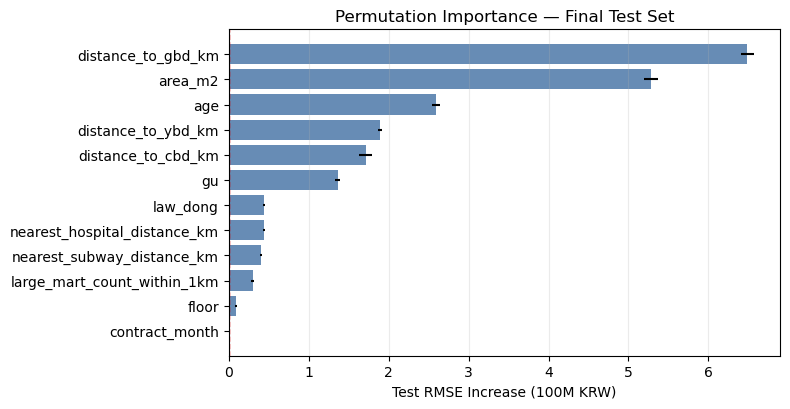

In [ ]:
# 시각화
# 막대는 평균 중요도, 끝의 선은 반복 permutation 결과의 표준편차
plot_df = perm_df.sort_values('importance_mean')
fig, ax = plt.subplots(figsize=(8, max(4, len(plot_df) * 0.35)))

ax.barh(plot_df['feature'], plot_df['importance_mean'] / 10_000, xerr=plot_df['importance_std'] / 10_000, color='#4C78A8', alpha=0.85)
ax.axvline(0, color='red', linewidth=1, linestyle='--')
ax.set_xlabel('Test RMSE Increase (100M KRW)')
ax.set_title('Permutation Importance — Final Test Set')
ax.grid(axis='x', alpha=0.25)

fig.tight_layout()
display(fig)
fig.savefig(FINAL_FIGURE_DIR / '06_2_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.close(fig)

## 6. 결과 해석 및 정리

### Permutation Importance vs Feature Importance 비교

두 방식 모두 `distance_to_gbd_km`과 `area_m2`가 1, 2위를 차지하며 순위가 일치한다. 트리 기반 Feature Importance에서 나타났던 두 변수 편중이 Permutation Importance에서도 동일하게 확인되므로, 해당 편중은 트리 분기 특성에 의한 편향이 아니라 실제 예측 기여도를 반영한 결과로 판단된다.

### 변수 중요도 편중에 대한 판단

`distance_to_gbd_km`(RMSE 증가 약 6.49억), `area_m2`(약 5.28억)가 압도적으로 높고, 이후 `age`(약 2.59억), `distance_to_ybd_km`(약 1.89억), `distance_to_cbd_km`(약 1.71억)가 뒤를 잇는다. 강남권 접근성과 전용면적이 서울 아파트 실거래가 예측에 가장 큰 영향을 미치는 변수임을 실증적으로 확인한다. `contract_month`는 중요도가 0으로 계절성 효과가 2025년 데이터에서 유의미하지 않음을 시사한다.

편중이 실제 데이터 구조에서 비롯된 것으로 확인되었으므로 추가 탐색 없이 현재 모델을 유지한다.